In [19]:
from google.colab import files

print("Please select the 'bank_transaction_analysis.csv' file to upload.")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Please select the 'bank_transaction_analysis.csv' file to upload.


Saving bank_transaction_analysis.csv to bank_transaction_analysis (1).csv
User uploaded file "bank_transaction_analysis (1).csv" with length 100749 bytes


In [20]:
import pandas as pd

df = pd.read_csv('bank_transaction_analysis.csv')

df.head()

,Transaction_ID,Customer_ID,Customer_Name,Gender,Age,Account_Type,Branch_ID,Branch_Name,City,Transaction_Date,...,Balance_After,Merchant_Category,Transaction_Status,Device_Type,Fraud_Flag,Risk_Score,Loan_Customer,Credit_Score,Salary_Band,Customer_Segment
0,TXN000001,CUST8927,Aarav Sharma,Male,37,Savings,BR118,Connaught Place Branch,Kolkata,2024-02-18,...,293095.08,E-commerce,Success,Desktop,No,4,No,567,6-10 LPA,HNI
1,TXN000002,CUST4086,Pooja Yadav,Female,64,Savings,BR114,Connaught Place Branch,Delhi,2024-05-08,...,215534.65,Education,Pending,Tablet,Yes,34,Yes,305,6-10 LPA,HNI
2,TXN000003,CUST3654,Karan Malhotra,Male,52,Current,BR110,Banjara Hills Branch,Ahmedabad,2024-04-11,...,266438.04,Utilities,Success,Desktop,No,5,No,868,0-3 LPA,HNI
3,TXN000004,CUST8245,Aditya Verma,Male,56,Savings,BR102,MG Road Branch,Kolkata,2024-01-06,...,475284.27,Retail,Success,Tablet,No,38,No,434,6-10 LPA,Retail
4,TXN000005,CUST3648,Priya Nair,Female,63,Savings,BR116,Fort Branch,Mumbai,2025-09-10,...,276332.03,Grocery,Failed,iPhone,No,90,No,836,6-10 LPA,Premium


Data Summary

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      500 non-null    object 
 1   Customer_ID         500 non-null    object 
 2   Customer_Name       500 non-null    object 
 3   Gender              500 non-null    object 
 4   Age                 500 non-null    int64  
 5   Account_Type        500 non-null    object 
 6   Branch_ID           500 non-null    object 
 7   Branch_Name         500 non-null    object 
 8   City                500 non-null    object 
 9   Transaction_Date    500 non-null    object 
 10  Transaction_Time    500 non-null    object 
 11  Transaction_Type    500 non-null    object 
 12  Channel             500 non-null    object 
 13  Amount              500 non-null    float64
 14  Balance_Before      500 non-null    float64
 15  Balance_After       500 non-null    float64
 16  Merchant

,Age,Amount,Balance_Before,Balance_After,Risk_Score,Credit_Score
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,43.904000,49755.36472,253935.327060,251811.794860,49.190000,610.296000
std,13.294822,29424.04739,136831.689262,145316.286043,28.643722,170.208432
min,21.000000,160.06000,5052.440000,0.000000,1.000000,302.000000
25%,32.000000,24813.36500,138973.297500,131779.235000,23.000000,472.750000
50%,45.000000,48708.14500,257049.060000,251065.770000,50.000000,613.500000
75%,55.000000,74293.31750,362088.725000,369608.327500,75.000000,762.500000
max,65.000000,99963.53000,498470.110000,569015.070000,100.000000,900.000000


Fraud Analysis

In [22]:
fraud=df[df['Fraud_Flag']=="Yes"]

print(fraud.shape)

(129, 25)


Branch Revenue

In [23]:
branch=df.groupby('Branch_Name')['Amount'].sum()

print(branch)

Branch_Name
Banjara Hills Branch      4718145.51
Connaught Place Branch    5796938.65
Fort Branch               4758001.15
MG Road Branch            5154402.55
Shivajinagar Branch       4450194.50
Name: Amount, dtype: float64


Top Customers

In [24]:
top=df.groupby('Customer_ID')['Amount'].sum()

top.sort_values(ascending=False).head(10)

,Amount
Customer_ID,
CUST9351,148463.97
CUST7260,138250.64
CUST7403,137546.23
CUST6413,131433.29
CUST6422,130630.23
CUST9789,129832.59
CUST8654,118582.21
CUST1247,116329.46
CUST9013,103497.16


Monthly Trend

In [25]:
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'])

monthly=df.groupby(
df['Transaction_Date'].dt.month
)['Amount'].sum().reset_index()

monthly

,Transaction_Date,Amount
0,1,2565979.80
1,2,2178741.11
2,3,1857108.06
3,4,1710026.49
4,5,2090841.97
5,6,2629824.60
6,7,1802961.85
7,8,2557762.21
8,9,2129578.43
9,10,1787014.11


In [26]:
print(df['Transaction_Date'].head(10))
print(df['Transaction_Date'].dtype)

0   2024-02-18
1   2024-05-08
2   2024-04-11
3   2024-01-06
4   2025-09-10
5   2025-02-03
6   2025-04-17
7   2024-11-18
8   2025-10-03
9   2024-11-30
Name: Transaction_Date, dtype: datetime64[ns]
datetime64[ns]


Visualization

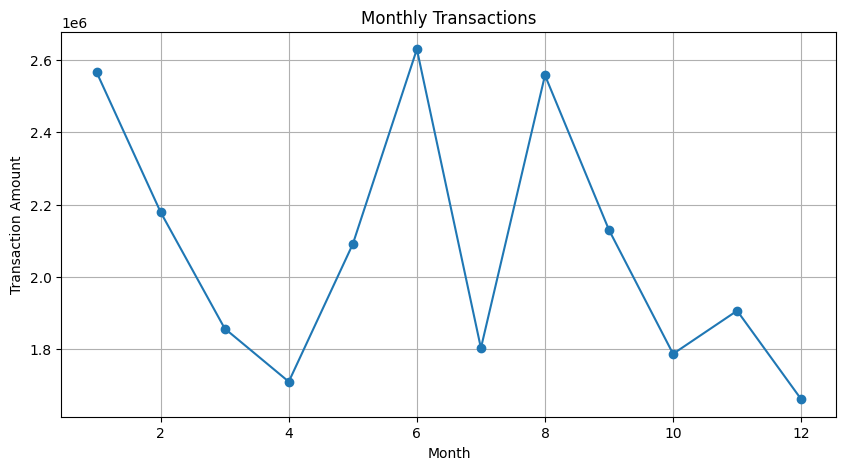

In [27]:
import matplotlib.pyplot as plt

monthly = df.groupby(
    df['Transaction_Date'].dt.month
)['Amount'].sum()

plt.figure(figsize=(10, 5))
monthly.plot(marker='o')

plt.title('Monthly Transactions')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.grid(True)

plt.show()

Fraud Chart

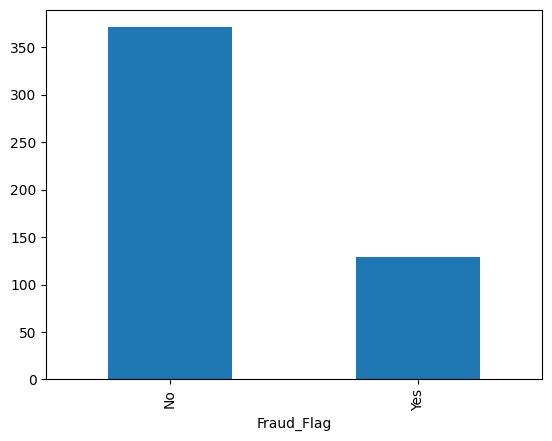

In [28]:
fraud_count=df['Fraud_Flag'].value_counts()

fraud_count.plot(kind='bar')

plt.show()

Transaction Statistics

In [29]:
import numpy as np

amounts = df['Amount'].values

print("Average Transaction:", np.mean(amounts))
print("Median Transaction:", np.median(amounts))
print("Maximum Transaction:", np.max(amounts))
print("Minimum Transaction:", np.min(amounts))
print("Standard Deviation:", np.std(amounts))

Average Transaction: 49755.36472
Median Transaction: 48708.145000000004
Maximum Transaction: 99963.53
Minimum Transaction: 160.06
Standard Deviation: 29394.608616320744


Risk Score Analysis

In [30]:
risk_scores = df['Risk_Score'].values

print("Average Risk Score:", np.mean(risk_scores))
print("95th Percentile:", np.percentile(risk_scores,95))

Average Risk Score: 49.19
95th Percentile: 92.04999999999995


Outlier Detection (High-Value Transactions)

In [36]:
# q1 = np.percentile(df['Amount'],25)
# q3 = np.percentile(df['Amount'],75)

# iqr = q3 - q1

# upper_limit = q3 + 1.5 * iqr

# outliers = df[df['Amount'] > upper_limit]

# print("Outlier Transactions:", len(outliers)) ----> op: Outlier Transactions: 0

q1 = np.percentile(df['Amount'], 25)
q3 = np.percentile(df['Amount'], 75)

iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper Limit:", upper_limit)
print("Maximum Amount:", df['Amount'].max())

Q1: 24813.364999999998
Q3: 74293.3175
IQR: 49479.95250000001
Upper Limit: 148513.24625000003
Maximum Amount: 99963.53


Customer Segmentation

In [34]:
conditions = [
    df['Amount'] < 5000,
    (df['Amount'] >= 5000) & (df['Amount'] < 20000),
    df['Amount'] >= 20000
]

segments = ['Low','Medium','High']

df['Spending_Category'] = np.select(
    conditions,
    segments,
    default='Unknown'
)
print(df[['Amount', 'Spending_Category']].head(10))

     Amount Spending_Category
0  57718.16              High
1  41484.39              High
2  47379.38              High
3  60017.28              High
4  81484.66              High
5  66081.13              High
6  67462.06              High
7  28868.70              High
8  95320.68              High
9  86957.88              High


Fraud Threshold Calculation

In [35]:
threshold = np.percentile(df['Amount'],99)

suspicious = df[df['Amount'] > threshold]

print(suspicious[['Transaction_ID','Amount']])

    Transaction_ID    Amount
169      TXN000170  98990.04
308      TXN000309  99394.42
320      TXN000321  99563.13
401      TXN000402  99963.53
417      TXN000418  99030.05
